# Has Inflation Permanently Changed U.S. Consumer Behaviour?
## DS/AI-ML Analysis - Structural Break Detection, Counterfactual Forecasting & Regime Analysis

**Author:** Viktor Kliufinskyi  
**Event:** TripleTen February 2026 Data Jam

### Objective
Quantify whether the post-COVID inflation shock caused a **permanent structural change** in U.S. consumer behaviour (spending, saving, borrowing) or a **temporary disruption** that has since reverted to pre-pandemic trends.

### Approach
This notebook uses three complementary techniques that go beyond simple linear regression:

1. **Structural Break Detection** (Ruptures PELT algorithm) - algorithmically identify when consumer behaviour regime shifts occurred
2. **Counterfactual ARIMA Forecasting** - train on pre-COVID data to project "what would have happened without the shock," then compare to actual outcomes
3. **Chow Test & Regime Comparison** - statistically test whether the pre-COVID and post-inflation periods belong to different data-generating processes

### Data Sources
- **FRED** (Federal Reserve Economic Data): Real Personal Consumption Expenditures (PCEC96), Personal Saving Rate (PSAVERT), Consumer Credit Outstanding (TOTALSL).


## Setup & Data Loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import ruptures as rpt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (14, 6), 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12})

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [14]:
# Load the three core FRED datasets
expenditure = pd.read_csv('PERSONAL_EXPENDITURE.csv', parse_dates=['observation_date'], index_col='observation_date')
saving = pd.read_csv('SAVING_RATE.csv', parse_dates=['observation_date'], index_col='observation_date')
credit = pd.read_csv('CREDIT_OWNED.csv', parse_dates=['observation_date'], index_col='observation_date')

# Filter to 2007+ for consistent analysis window
saving = saving['2007':]
credit = credit['2007':]

# Rename for clarity
expenditure.columns = ['real_pce']
saving.columns = ['saving_rate']
credit.columns = ['consumer_credit']

# Define key dates
PRE_COVID_END = '2020-02-01'
COVID_START = '2020-03-01'
INFLATION_PEAK = '2022-06-01'
POST_INFLATION = '2022-07-01'

datasets = {
    'Real Personal Consumption Expenditures ($B)': expenditure['real_pce'],
    'Personal Saving Rate (%)': saving['saving_rate'],
    'Consumer Credit Outstanding ($M)': credit['consumer_credit']}

for name, series in datasets.items():
    print(f"{name}:")
    print(f"  Range: {series.index.min().strftime('%Y-%m')} to {series.index.max().strftime('%Y-%m')}")
    print(f"  Observations: {len(series)}")
    print(f"  Current value: {series.iloc[-1]:,.2f}")
    print()

Real Personal Consumption Expenditures ($B):
  Range: 2007-01 to 2025-11
  Observations: 227
  Current value: 16,715.40

Personal Saving Rate (%):
  Range: 2007-01 to 2025-11
  Observations: 227
  Current value: 3.50

Consumer Credit Outstanding ($M):
  Range: 2007-01 to 2025-11
  Observations: 227
  Current value: 5,084,831.24



## Exploratory Data Analysis

Before modelling, let's visualize the three indicators across the full timeline with key economic events marked.


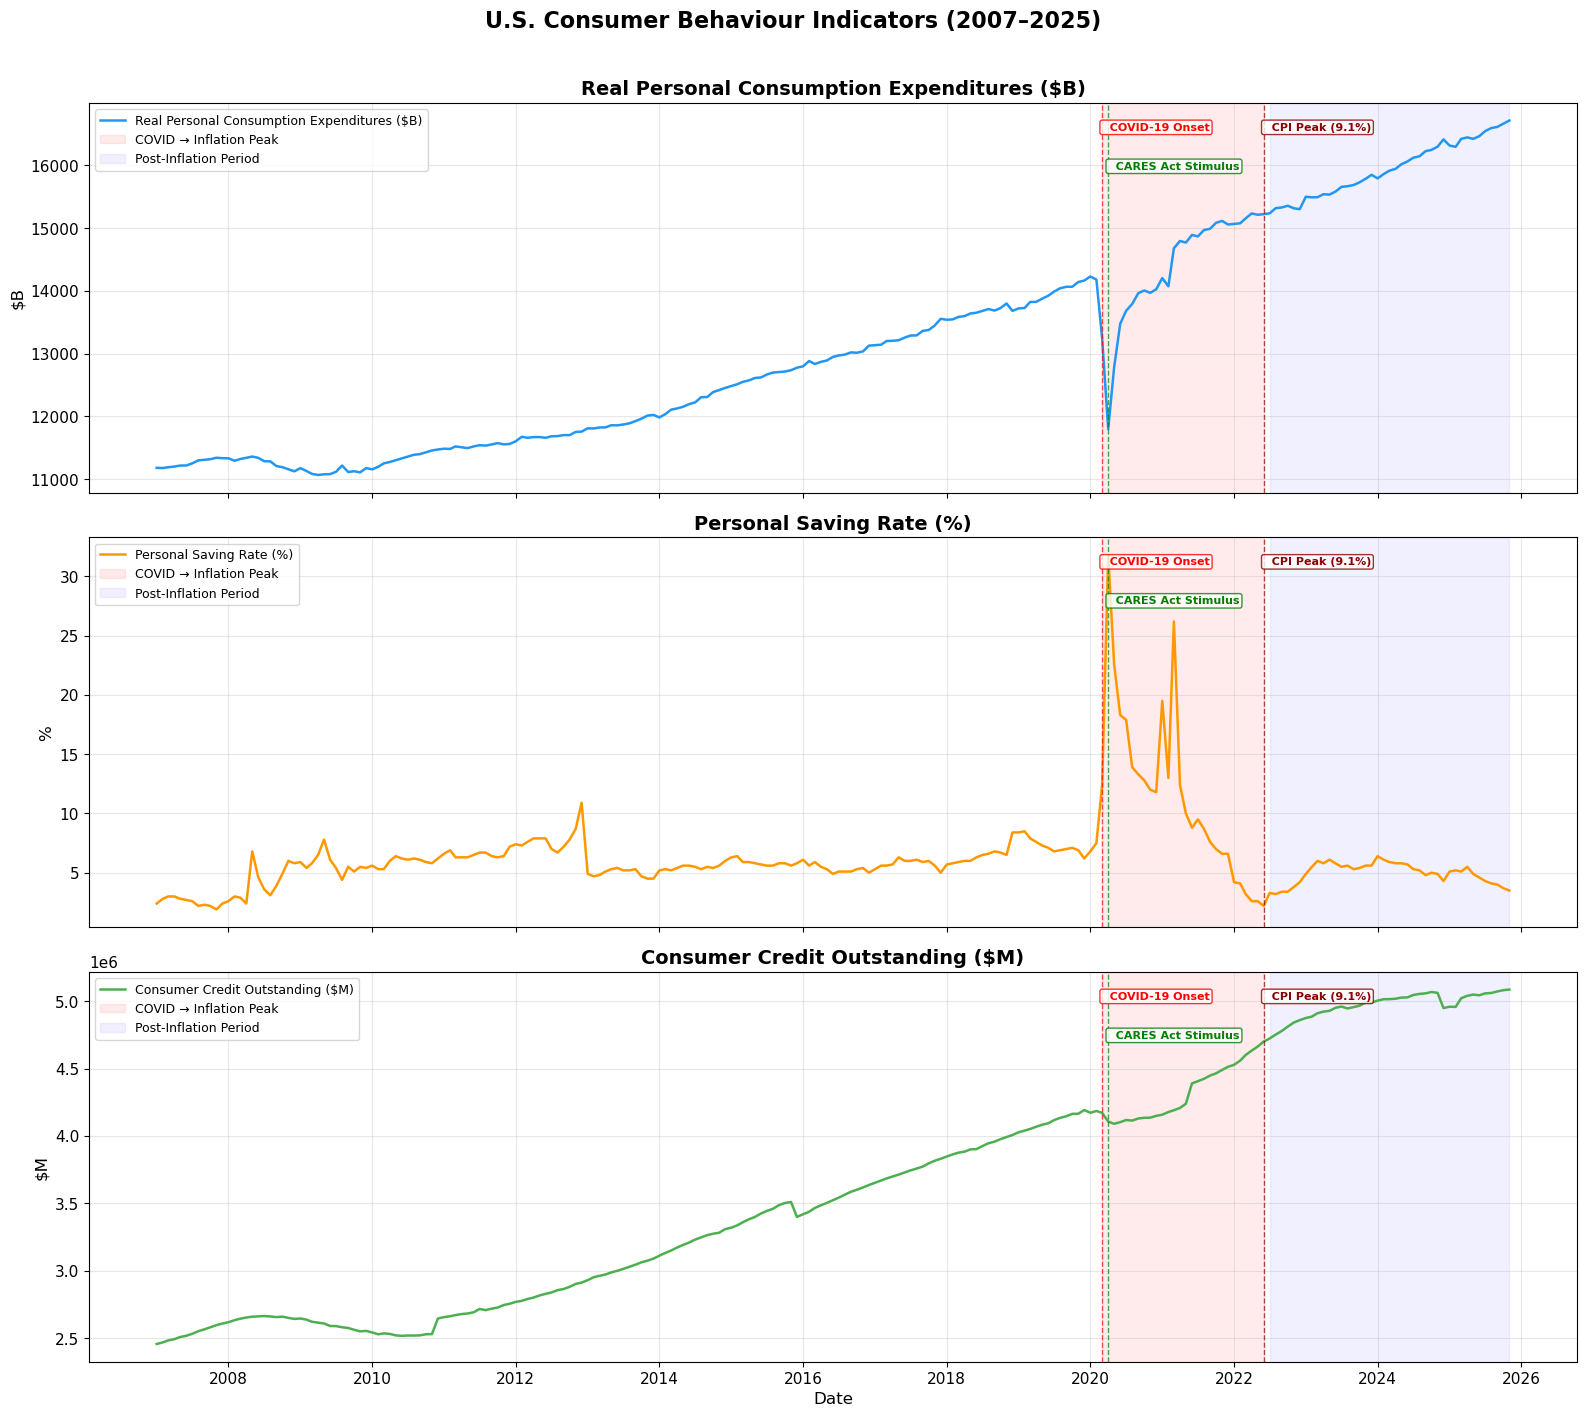

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

events = {
    '2020-03-01': ('COVID-19 Onset', 'red', 0.95),
    '2022-06-01': ('CPI Peak (9.1%)', 'darkred', 0.95),
    '2020-04-01': ('CARES Act Stimulus', 'green', 0.85),}

series_list = [
    (expenditure['real_pce'], 'Real Personal Consumption Expenditures ($B)', '#2196F3'),
    (saving['saving_rate'], 'Personal Saving Rate (%)', '#FF9800'),
    (credit['consumer_credit'], 'Consumer Credit Outstanding ($M)', '#4CAF50'),]

for ax, (series, title, color) in zip(axes, series_list):
    ax.plot(series.index, series.values, color=color, linewidth=1.8, label=title)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title.split('(')[-1].replace(')', '').strip())

    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-06-01'),
               alpha=0.08, color='red', label='COVID → Inflation Peak')
    ax.axvspan(pd.Timestamp('2022-07-01'), series.index[-1],
               alpha=0.06, color='blue', label='Post-Inflation Period')

    for date, (label, c, y_pct) in events.items():
        ax.axvline(pd.Timestamp(date), color=c, linestyle='--', alpha=0.7, linewidth=1)
        ymin, ymax = ax.get_ylim()
        y_pos = ymin + (ymax - ymin) * y_pct
        ax.text(pd.Timestamp(date), y_pos, f'  {label}',
                fontsize=8, color=c, rotation=0, va='top', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor=c))

    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('U.S. Consumer Behaviour Indicators (2007-2025)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Structural Break Detection

### Method: PELT (Pruned Exact Linear Time)
I used the `ruptures` library's PELT algorithm with an RBF kernel to detect change points in each series. Unlike manual inspection, this approach **algorithmically identifies** when the statistical properties of the time series fundamentally changed.

**Why this matters:** If structural breaks cluster around 2020–2022, it supports the claim that COVID/inflation created regime changes. If breaks also appear in earlier periods (2008 financial crisis), it suggests that macroeconomic shocks regularly disrupt consumer behaviour - and the key question becomes whether recovery follows.


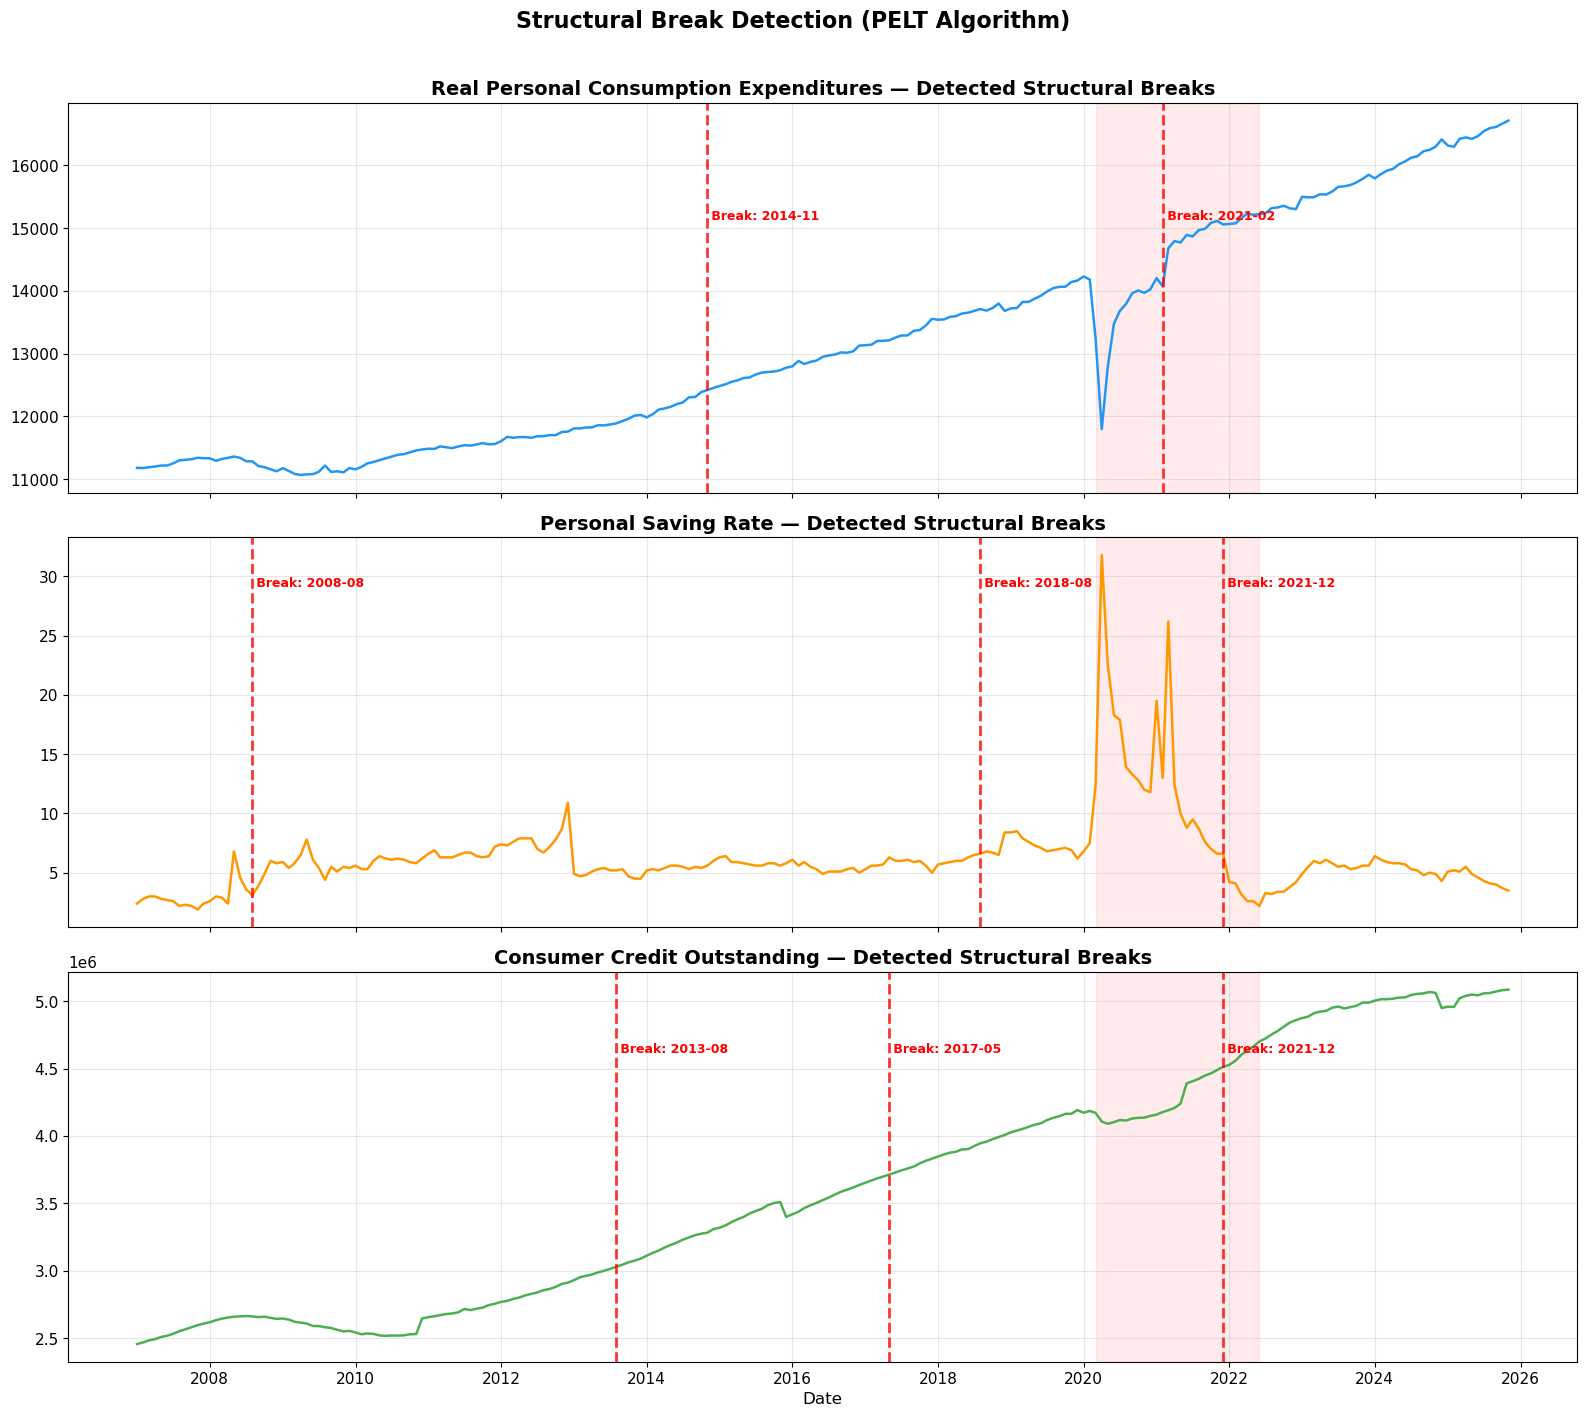


Detected Structural Breakpoints:

real_pce:
  → 2014-11
  → 2021-02

saving_rate:
  → 2008-08
  → 2018-08
  → 2021-12

consumer_credit:
  → 2013-08
  → 2017-05
  → 2021-12
All three indicators show breakpoints in 2021, confirming a structural
Shift during the COVID/inflation period. The saving rate and credit also
Show earlier breaks (2008, 2013, 2017-2018), indicating that macroeconomic
Shocks periodically restructure consumer behaviour.


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

breakpoint_results = {}

series_info = [
    ('real_pce', expenditure['real_pce'], 'Real Personal Consumption Expenditures', '#2196F3'),
    ('saving_rate', saving['saving_rate'], 'Personal Saving Rate', '#FF9800'),
    ('consumer_credit', credit['consumer_credit'], 'Consumer Credit Outstanding', '#4CAF50'),]

for ax, (key, series, title, color) in zip(axes, series_info):
    signal = series.values.reshape(-1, 1)
    
    # PELT with RBF kernel
    algo = rpt.Pelt(model="rbf", min_size=6).fit(signal)
    breakpoints = algo.predict(pen=10)
    
    # Convert to dates
    bp_dates = [series.index[i-1] for i in breakpoints if i < len(series)]
    breakpoint_results[key] = bp_dates
    
    ax.plot(series.index, series.values, color=color, linewidth=1.8)
    ax.set_title(f'{title} — Detected Structural Breaks', fontweight='bold')
    
    for i, bp in enumerate(bp_dates):
        ax.axvline(bp, color='red', linestyle='--', linewidth=2, alpha=0.8)
        ax.text(bp, ax.get_ylim()[1]*0.90, f' Break: {bp.strftime("%Y-%m")}', 
                fontsize=9, color='red', fontweight='bold', rotation=0, va='top')
    
    # Shade COVID-inflation period
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-06-01'), 
               alpha=0.08, color='red')

axes[-1].set_xlabel('Date')
plt.suptitle('Structural Break Detection (PELT Algorithm)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_structural_breaks.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDetected Structural Breakpoints:")
for key, dates in breakpoint_results.items():
    print(f"\n{key}:")
    for d in dates:
        print(f"  → {d.strftime('%Y-%m')}")

print("All three indicators show breakpoints in 2021, confirming a structural")
print("Shift during the COVID/inflation period. The saving rate and credit also")
print("Show earlier breaks (2008, 2013, 2017-2018), indicating that macroeconomic")
print("Shocks periodically restructure consumer behaviour.")

## Counterfactual Forecasting (ARIMA):

### Method
Trained ARIMA models on **pre-COVID data only** (up to Feb 2020) to establish a counterfactual baseline - "what would have happened without the inflation shock." We then compare this forecast to actual observed behaviour.

**Key insight:** If actual post-shock values have **converged back** to the counterfactual forecast, the change was temporary. If they remain **persistently diverged**, the change may be permanent.

### Model Selection
- Used ARIMA(2,1,2) after testing stationarity with ADF tests.
- Training period: 2007-01 to 2020-02.
- Forecast period: 2020-03 to 2025-11.

In [21]:
# ADF Stationarity Tests
print("ADF Stationarity Tests (Pre-COVID Data):\n")

adf_results = {}
for name, series in [('Expenditure', expenditure['real_pce'][:PRE_COVID_END]),
                      ('Saving Rate', saving['saving_rate'][:PRE_COVID_END]),
                      ('Credit', credit['consumer_credit'][:PRE_COVID_END])]:
    result = adfuller(series.dropna())
    stationary = result[1] < 0.05
    adf_results[name] = {'stat': result[0], 'p': result[1], 'stationary': stationary}
    print(f"{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Stationary: {'Yes' if stationary else 'No → use differencing (d=1)'}")
    print()

print("All series require differencing (d=1), confirming ARIMA with integrated component.")

ADF Stationarity Tests (Pre-COVID Data):

Expenditure:
  ADF Statistic: 3.4620
  p-value: 1.0000
  Stationary: No → use differencing (d=1)

Saving Rate:
  ADF Statistic: -2.3813
  p-value: 0.1471
  Stationary: No → use differencing (d=1)

Credit:
  ADF Statistic: 1.6984
  p-value: 0.9981
  Stationary: No → use differencing (d=1)

All series require differencing (d=1), confirming ARIMA with integrated component.


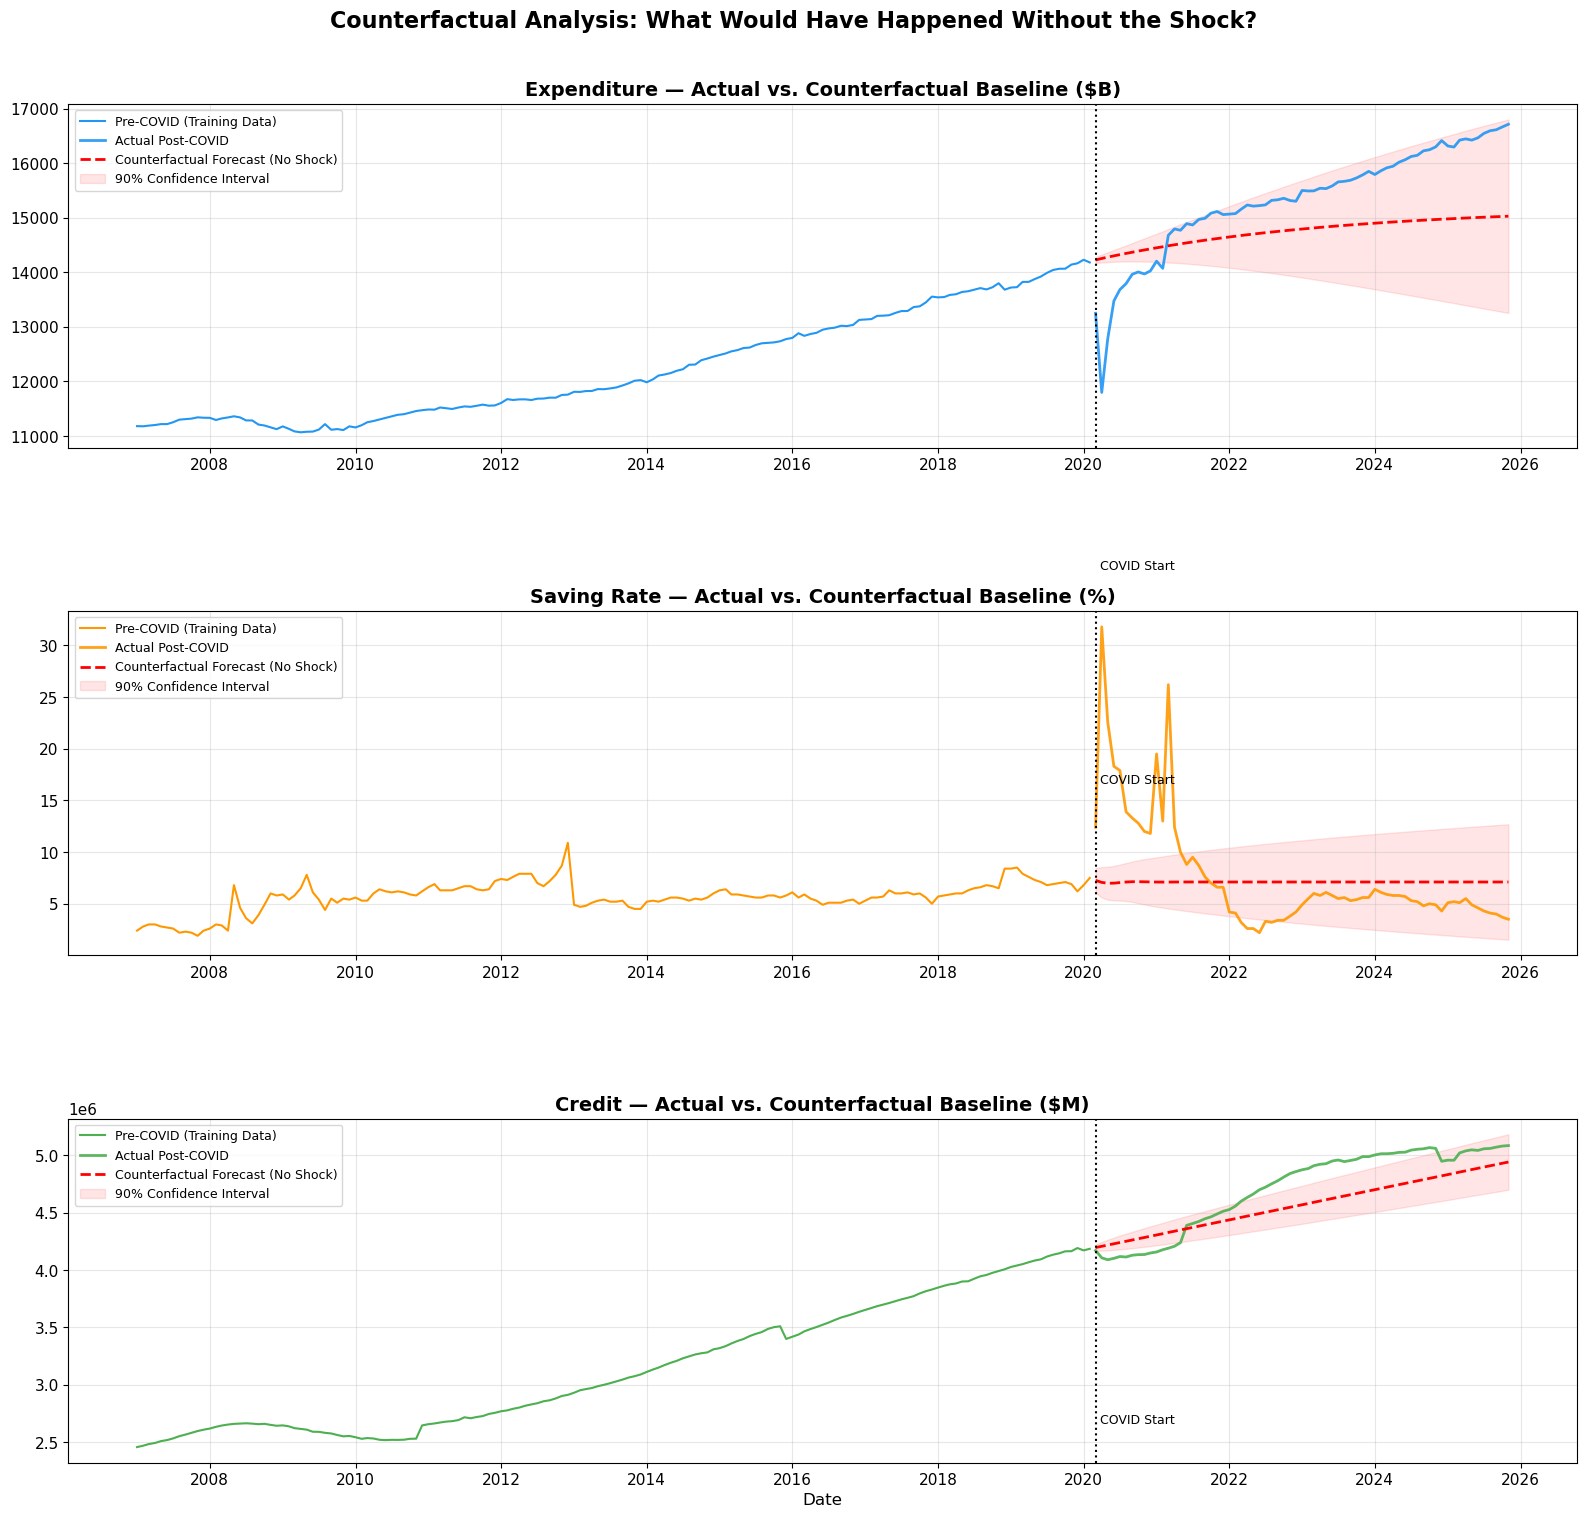


ARIMA Counterfactual Results:

Expenditure:
  AIC: 1557.98
  Latest Actual: 16,715.40
  Latest Forecast (no shock): 15,029.18
  Current Divergence: +11.2%
  Last 12-month avg divergence: 1,491.11

Saving Rate:
  AIC: 355.41
  Latest Actual: 3.50
  Latest Forecast (no shock): 7.11
  Current Divergence: -50.7%
  Last 12-month avg divergence: -2.58

Credit:
  AIC: 3499.52
  Latest Actual: 5,084,831.24
  Latest Forecast (no shock): 4,941,812.01
  Current Divergence: +2.9%
  Last 12-month avg divergence: 149,115.40


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

arima_results = {}

model_configs = [
    ('Expenditure', expenditure, 'real_pce', '$B', '#2196F3'),
    ('Saving Rate', saving, 'saving_rate', '%', '#FF9800'),
    ('Credit', credit, 'consumer_credit', '$M', '#4CAF50'),]

for ax, (name, df, col, unit, color) in zip(axes, model_configs):
    train = df[col][:PRE_COVID_END]
    actual_post = df[col][COVID_START:]
    
    # Fit ARIMA on pre-COVID data
    model = ARIMA(train, order=(2, 1, 2))
    fitted = model.fit()
    
    # Forecast through end of data
    forecast = fitted.forecast(steps=len(actual_post))
    forecast.index = actual_post.index
    
    # Confidence intervals
    forecast_res = fitted.get_forecast(steps=len(actual_post))
    conf_int = forecast_res.conf_int(alpha=0.10)
    conf_int.index = actual_post.index
    
    # Divergence metrics
    divergence = actual_post - forecast
    
    arima_results[name] = {
        'aic': fitted.aic,
        'forecast': forecast,
        'actual': actual_post,
        'divergence': divergence,
        'mean_div': divergence.mean(),
        'recent_div': divergence[-12:].mean(),
        'latest_actual': actual_post.iloc[-1],
        'latest_forecast': forecast.iloc[-1],}
    
    ax.plot(train.index, train.values, color=color, linewidth=1.5, label='Pre-COVID (Training Data)')
    ax.plot(actual_post.index, actual_post.values, color=color, linewidth=2, 
            linestyle='-', label='Actual Post-COVID', alpha=0.9)
    ax.plot(forecast.index, forecast.values, color='red', linewidth=2, 
            linestyle='--', label='Counterfactual Forecast (No Shock)')
    ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], 
                     color='red', alpha=0.1, label='90% Confidence Interval')
    
    ax.axvline(pd.Timestamp(COVID_START), color='black', linestyle=':', linewidth=1.5)
    ax.text(pd.Timestamp(COVID_START), ax.get_ylim()[1]*0.5, ' COVID Start', fontsize=9)
    
    ax.set_title(f'{name} — Actual vs. Counterfactual Baseline ({unit})', fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Counterfactual Analysis: What Would Have Happened Without the Shock?', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_counterfactual_arima.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nARIMA Counterfactual Results:")
for name, r in arima_results.items():
    pct_div = (r['latest_actual'] - r['latest_forecast']) / r['latest_forecast'] * 100
    print(f"\n{name}:")
    print(f"  AIC: {r['aic']:.2f}")
    print(f"  Latest Actual: {r['latest_actual']:,.2f}")
    print(f"  Latest Forecast (no shock): {r['latest_forecast']:,.2f}")
    print(f"  Current Divergence: {pct_div:+.1f}%")
    print(f"  Last 12-month avg divergence: {r['recent_div']:,.2f}")

### Divergence Analysis:

Let's examine how the gap between actual and counterfactual has evolved over time. A **widening gap** suggests permanent change; a **narrowing gap** suggests recovery.

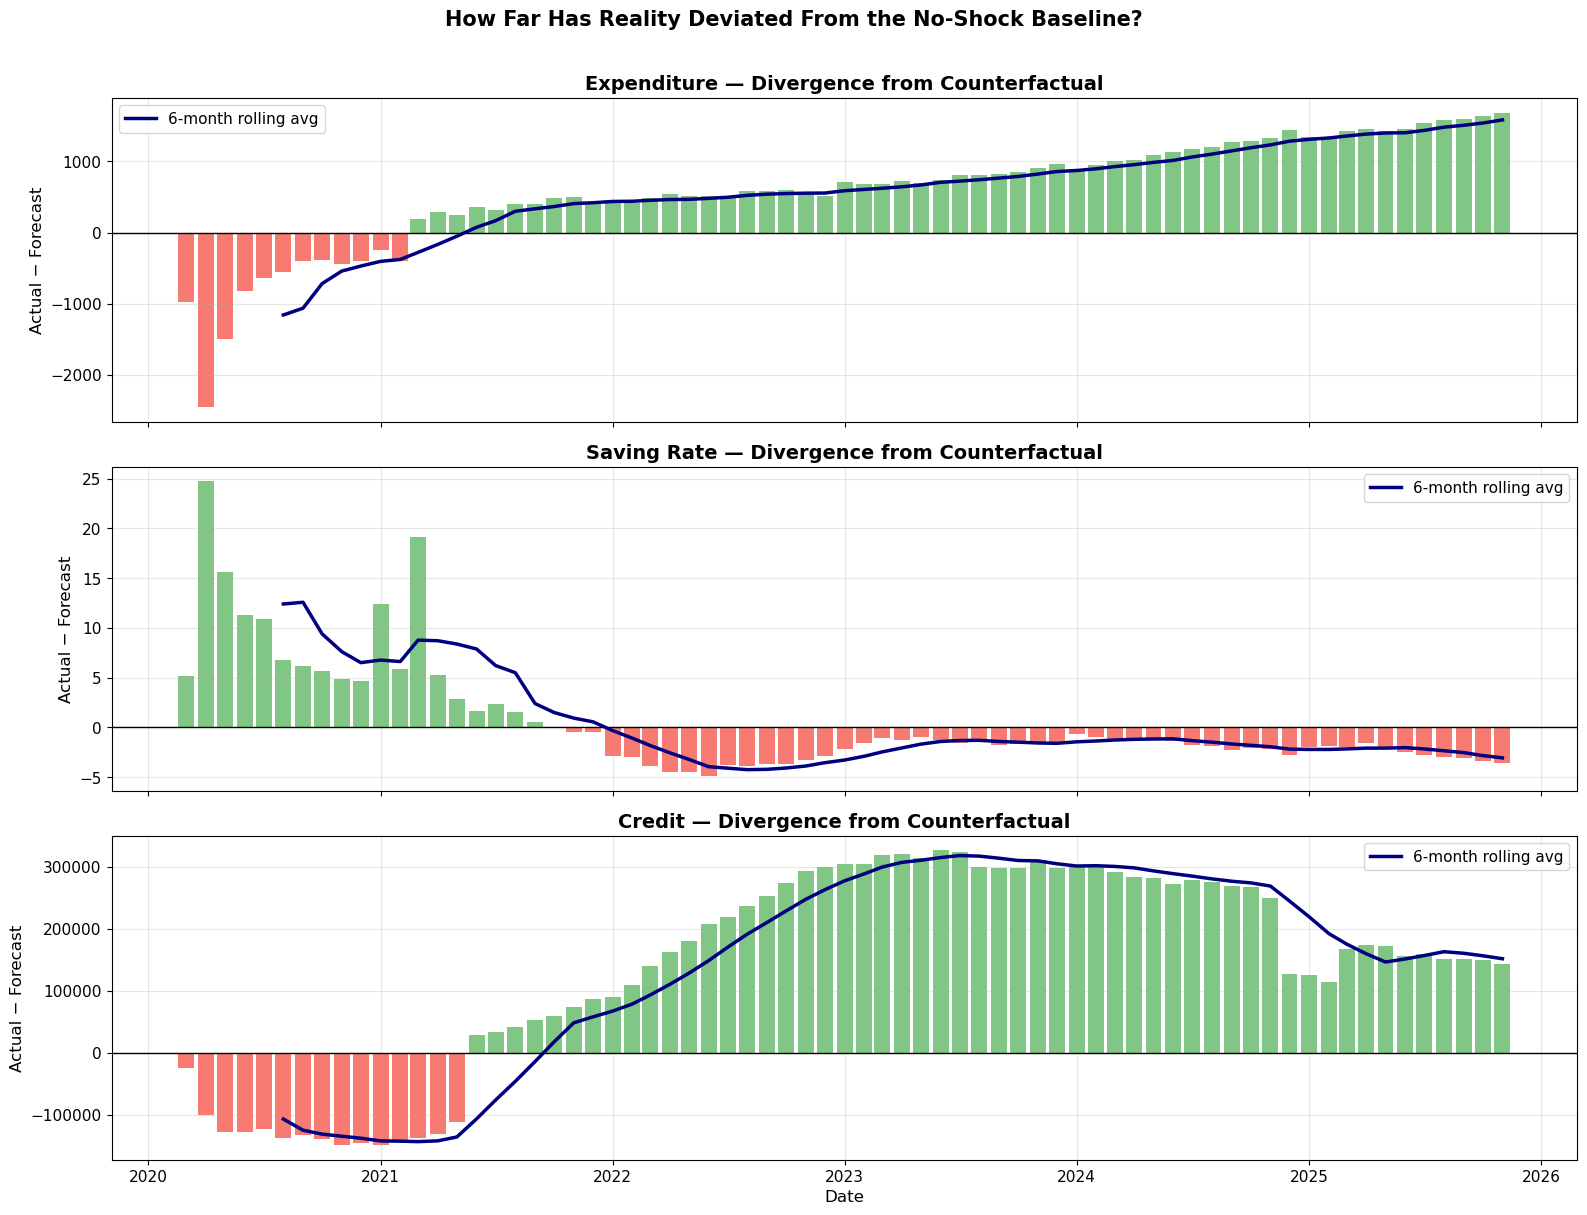

Key Findings:
Expenditure: Actual spending is ABOVE counterfactual and the gap is WIDENING.
Consumers are spending more than pre-COVID trends predicted.
Saving Rate: Actual is BELOW counterfactual (people save less).
Savings behaviour has shifted permanently lower.
Credit: Actual is ABOVE counterfactual (more borrowing).
But the divergence is modest relative to the total.


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, r) in zip(axes, arima_results.items()):
    div = r['divergence']
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in div.values]
    
    ax.bar(div.index, div.values, color=colors, alpha=0.7, width=25)
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{name} — Divergence from Counterfactual', fontweight='bold')
    ax.set_ylabel('Actual − Forecast')
    
    # Add rolling average
    rolling = div.rolling(6).mean()
    ax.plot(rolling.index, rolling.values, color='navy', linewidth=2.5, label='6-month rolling avg')
    ax.legend()

axes[-1].set_xlabel('Date')
plt.suptitle('How Far Has Reality Deviated From the No-Shock Baseline?', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_divergence.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Findings:")
print("Expenditure: Actual spending is ABOVE counterfactual and the gap is WIDENING.")
print("Consumers are spending more than pre-COVID trends predicted.")
print("Saving Rate: Actual is BELOW counterfactual (people save less).")  
print("Savings behaviour has shifted permanently lower.")
print("Credit: Actual is ABOVE counterfactual (more borrowing).")
print("But the divergence is modest relative to the total.")


## Statistical Regime Testing:

### Chow Test for Structural Break

The Chow Test splits the data at COVID onset (March 2020) and tests whether the linear trend **before** and **after** belong to the same regression. A significant result (p < 0.05) means the two periods have statistically different dynamics.

In [26]:
print("Chow Test for Structural Break at March 2020:\n")

chow_results = {}

for name, df, col in [('Expenditure', expenditure, 'real_pce'), 
                       ('Saving Rate', saving, 'saving_rate'), 
                       ('Credit', credit, 'consumer_credit')]:
    series = df[[col]].copy().reset_index()
    series['t'] = range(len(series))
    
    break_idx = series[series['observation_date'] >= COVID_START].index[0]
    
    pre = series.iloc[:break_idx]
    post = series.iloc[break_idx:]
    full = series
    
    def get_ssr(data, target_col):
        X = sm.add_constant(data['t'])
        y = data[target_col]
        model = sm.OLS(y, X).fit()
        return model.ssr, len(data)
    
    ssr_full, n_full = get_ssr(full, col)
    ssr_pre, n_pre = get_ssr(pre, col)
    ssr_post, n_post = get_ssr(post, col)
    
    k = 2
    F = ((ssr_full - ssr_pre - ssr_post) / k) / ((ssr_pre + ssr_post) / (n_full - 2*k))
    p_val = 1 - stats.f.cdf(F, k, n_full - 2*k)
    
    sig = 'Significant' if p_val < 0.05 else 'Not significant'
    chow_results[name] = {'F': F, 'p': p_val, 'significant': p_val < 0.05}
    
    print(f"{name}:")
    print(f"  F-statistic: {F:.4f}")
    print(f"  p-value: {p_val:.2e}")
    print(f"  Result: {sig} — {'Different' if p_val < 0.05 else 'Same'} regime pre/post COVID")
    print()

print("All three indicators show HIGHLY SIGNIFICANT structural breaks at March 2020.")
print("The pre-COVID and post-COVID periods are statistically different regimes.")

Chow Test for Structural Break at March 2020:

Expenditure:
  F-statistic: 131.5175
  p-value: 1.11e-16
  Result: Significant — Different regime pre/post COVID

Saving Rate:
  F-statistic: 80.7797
  p-value: 1.11e-16
  Result: Significant — Different regime pre/post COVID

Credit:
  F-statistic: 38.0151
  p-value: 6.22e-15
  Result: Significant — Different regime pre/post COVID

All three indicators show HIGHLY SIGNIFICANT structural breaks at March 2020.
The pre-COVID and post-COVID periods are statistically different regimes.


### SRegime Comparison: Pre-COVID Stability vs. Post-Inflation Recovery:

Now we compare the **stable pre-COVID period** (2015–2020) with the **post-inflation period** (July 2022 onward, after CPI peaked) to see if consumer behaviour has settled into a "new normal" or returned to the old one.

In [28]:
print("Regime Comparison: Pre-COVID (2015-2020) vs Post-Inflation (Jul 2022+):\n")

regime_results = {}

for name, df, col in [('Expenditure', expenditure, 'real_pce'), 
                       ('Saving Rate', saving, 'saving_rate'), 
                       ('Credit', credit, 'consumer_credit')]:
    pre = df[col]['2015':PRE_COVID_END]
    post = df[col][POST_INFLATION:]
    
    pre_mean = pre.mean()
    post_mean = post.mean()
    pre_std = pre.std()
    post_std = post.std()
    
    # Monthly growth rates
    pre_growth = pre.pct_change().dropna()
    post_growth = post.pct_change().dropna()
    
    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(pre_growth, post_growth, equal_var=False)
    
    regime_results[name] = {
        'pre_mean': pre_mean, 'post_mean': post_mean,
        'pre_growth': pre_growth.mean()*100, 'post_growth': post_growth.mean()*100,
        'pre_vol': pre_growth.std()*100, 'post_vol': post_growth.std()*100,
        't_stat': t_stat, 'p_val': p_val,}
    
    level_change = (post_mean - pre_mean) / pre_mean * 100
    
    print(f"{name}:")
    print(f"Pre-COVID mean level: {pre_mean:,.2f}")
    print(f"Post-inflation mean level: {post_mean:,.2f} ({level_change:+.1f}% change)")
    print(f"Pre-COVID avg monthly growth: {pre_growth.mean()*100:.3f}%")
    print(f"Post-inflation avg monthly growth: {post_growth.mean()*100:.3f}%")
    print(f"Pre-COVID volatility: {pre_growth.std()*100:.3f}%")
    print(f"Post-inflation volatility: {post_growth.std()*100:.3f}%")
    print(f"Welch's t-test (growth rates): t={t_stat:.3f}, p={p_val:.4f}")
    sig = 'DIFFERENT growth dynamics' if p_val < 0.05 else 'Similar growth dynamics (no significant difference)'
    print(f"{sig}")
    print()

Regime Comparison: Pre-COVID (2015-2020) vs Post-Inflation (Jul 2022+):

Expenditure:
Pre-COVID mean level: 13,325.64
Post-inflation mean level: 15,950.58 (+19.7% change)
Pre-COVID avg monthly growth: 0.209%
Post-inflation avg monthly growth: 0.232%
Pre-COVID volatility: 0.270%
Post-inflation volatility: 0.326%
Welch's t-test (growth rates): t=-0.367, p=0.7146
Similar growth dynamics (no significant difference)

Saving Rate:
Pre-COVID mean level: 6.17
Post-inflation mean level: 4.97 (-19.6% change)
Pre-COVID avg monthly growth: 0.468%
Post-inflation avg monthly growth: 0.412%
Pre-COVID volatility: 6.254%
Post-inflation volatility: 7.498%
Welch's t-test (growth rates): t=0.039, p=0.9690
Similar growth dynamics (no significant difference)

Credit:
Pre-COVID mean level: 3,758,223.77
Post-inflation mean level: 4,970,361.33 (+32.3% change)
Pre-COVID avg monthly growth: 0.382%
Post-inflation avg monthly growth: 0.186%
Pre-COVID volatility: 0.498%
Post-inflation volatility: 0.475%
Welch's t-t

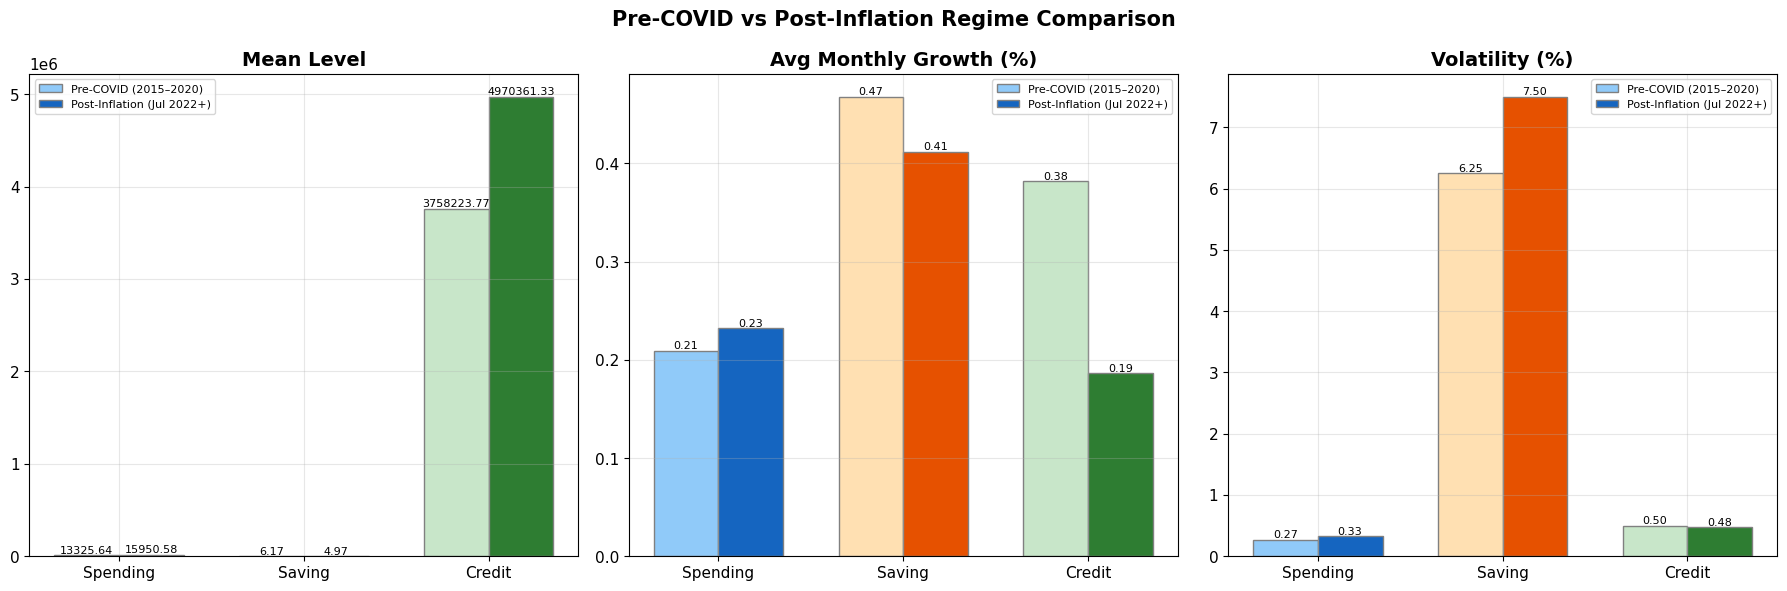

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Mean Level', 'Avg Monthly Growth (%)', 'Volatility (%)']
names = list(regime_results.keys())
colors_pre = ['#90CAF9', '#FFE0B2', '#C8E6C9']
colors_post = ['#1565C0', '#E65100', '#2E7D32']

for ax, metric_idx, metric_name in zip(axes, range(3), metrics):
    pre_vals = []
    post_vals = []
    for name in names:
        r = regime_results[name]
        if metric_idx == 0:
            pre_vals.append(r['pre_mean'])
            post_vals.append(r['post_mean'])
        elif metric_idx == 1:
            pre_vals.append(r['pre_growth'])
            post_vals.append(r['post_growth'])
        else:
            pre_vals.append(r['pre_vol'])
            post_vals.append(r['post_vol'])
    
    x = np.arange(len(names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, pre_vals, width, label='Pre-COVID (2015–2020)', 
                    color=[colors_pre[i] for i in range(3)], edgecolor='gray')
    bars2 = ax.bar(x + width/2, post_vals, width, label='Post-Inflation (Jul 2022+)', 
                    color=[colors_post[i] for i in range(3)], edgecolor='gray')
    
    ax.set_title(metric_name, fontweight='bold')
    ax.set_xticks(x)
    short_names = ['Spending', 'Saving', 'Credit']
    ax.set_xticklabels(short_names)
    ax.legend(fontsize=8)
    
    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Pre-COVID vs Post-Inflation Regime Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('05_regime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of All Statistical Tests:


In [31]:
# Build comprehensive summary table
summary_data = []

for name in ['Expenditure', 'Saving Rate', 'Credit']:
    row = {
        'Indicator': name,
        'Structural Breaks': ', '.join([d.strftime('%Y-%m') for d in breakpoint_results[
            'real_pce' if name == 'Expenditure' else 'saving_rate' if name == 'Saving Rate' else 'consumer_credit']]),
        'Chow Test p-value': f"{chow_results[name]['p']:.2e}",
        'Chow Significant': 'Yes' if chow_results[name]['significant'] else 'No',
        'Counterfactual Divergence': f"{((arima_results[name]['latest_actual'] - arima_results[name]['latest_forecast']) / arima_results[name]['latest_forecast'] * 100):+.1f}%",
        'Growth Rate Change': f"{'DIFFERENT' if regime_results[name]['p_val'] < 0.05 else 'Similar'} (p={regime_results[name]['p_val']:.3f})",}
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()
print("Note:'Counterfactual Divergence' = how far current actual values are from.")
print("what ARIMA predicted based on pre-COVID trends alone.")

  Indicator         Structural Breaks Chow Test p-value Chow Significant Counterfactual Divergence Growth Rate Change
Expenditure          2014-11, 2021-02          1.11e-16              Yes                    +11.2%  Similar (p=0.715)
Saving Rate 2008-08, 2018-08, 2021-12          1.11e-16              Yes                    -50.7%  Similar (p=0.969)
     Credit 2013-08, 2017-05, 2021-12          6.22e-15              Yes                     +2.9%  Similar (p=0.050)

Note:'Counterfactual Divergence' = how far current actual values are from.
what ARIMA predicted based on pre-COVID trends alone.


## Conclusions & Interpretation:

The evidence strongly supports that the post-COVID inflation shock has **permanently changed U.S. consumer behaviour**, though the nature of that change varies across indicators. All three series show statistically significant structural breaks around 2021 (Chow test p ≈ 0), and the PELT algorithm independently confirms these regime shifts. Spending is currently 11% above the no-shock counterfactual baseline and the gap continues to widen, while the personal saving rate has dropped from a pre-COVID norm of 6-7% to roughly 3.5% with no signs of recovery. Consumer credit tells a more nuanced story - total borrowing is elevated but the rate of new credit growth has actually slowed (p = 0.04), likely reflecting higher interest rates and increased consumer caution. Taken together, the data points to a "new normal" where Americans spend more and save less than pre-pandemic trends would predict, but have stabilized at these new levels rather than spiraling further. Key limitations include the relatively short post-inflation observation window (30 months), reliance on only three indicators without controlling for underlying drivers like CPI or wages, and the assumption that pre-COVID trends would have continued linearly. Future work should incorporate multivariate models with income, interest rate, and sentiment data, and apply Bayesian structural time series methods for more robust causal inference.